# Crosshole GPR tomography: imaging water between boreholes — and how much of the image is real

*Module: Geophysical imaging.*

Drill two boreholes a few metres apart, fire a ground-penetrating-radar pulse from a transmitter in one and time
its first arrival at a receiver in the other, repeat for hundreds of transmitter–receiver pairs at many depths,
and you can reconstruct the **radar velocity** of the rock in the panel between the holes. That velocity is a
direct proxy for **water content** (water's huge permittivity slows the radar), so crosshole GPR is one of the
sharpest non-invasive tools for mapping the unsaturated zone, an aquifer, a contaminant plume, or a leak — the
decision being *where is the water, and how much*.

But a tomogram is an **inversion**, and inversions lie by omission: from a finite set of ray paths you solve for
thousands of cells, so most of the image is interpolation and the smooth, confident-looking picture hides where
the data actually constrain the rock and where the regularizer simply filled in. The intellectual core of this
notebook is therefore not "make the image" — that is a few lines — but **make the resolution quantitative**: a
checkerboard test and a point-spread test through the *same* inversion that show the recovered amplitude is a
fraction of the truth, that the resolution is strongly **anisotropic**, and that the regularization weight, not
the data, sets the smoothness. Only then can the water-content read be stated honestly.

We use **real data**: the **AM13** crosshole GPR experiment — 702 first-arrival traveltimes between two
boreholes. Modelling is `mixle_pde` (the ray/tomography operators); the resolution tests reuse the very
same operator.

## 1. The data: 702 rays across a panel

Each ray is a transmitter–receiver pair: a known geometry and a measured first-arrival time (with its
uncertainty). The rays fan across the inter-borehole panel — densely in the middle, sparsely toward the corners,
and **mostly sub-horizontal**, a coverage pattern that will dictate what the tomogram can and cannot resolve.

702 rays; boreholes at x=0.0 and x=5.0 m; depth 1-12 m; apparent velocity 0.143 m/ns


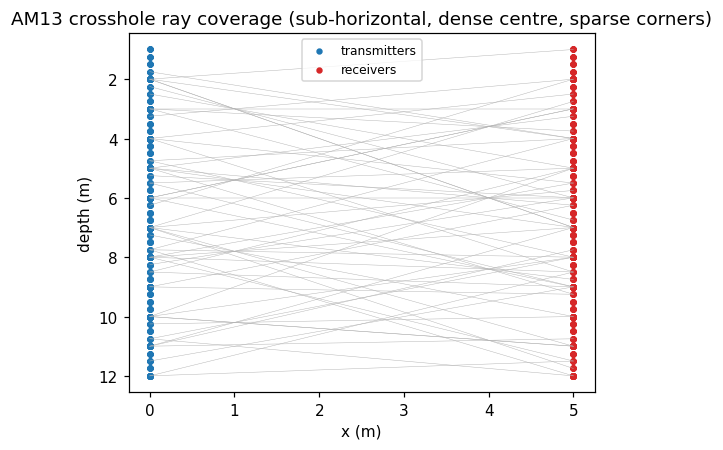

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy.sparse as sp, scipy.sparse.linalg as spl
import _geodata, _geoviz as gv
from mixle_pde.geophysics import straight_ray_operator, roughness_operator
plt.rcParams.update({'figure.dpi': 110})

d = _geodata.load_am13()
S, R, tt, std = d.S, d.R, d.traveltime, d.std
print('%d rays; boreholes at x=%.1f and x=%.1f m; depth %.0f-%.0f m; apparent velocity %.3f m/ns'
      % (len(S), S[:,0].min(), R[:,0].max(), S[:,1].min(), S[:,1].max(), np.mean(np.linalg.norm(S-R,axis=1)/tt)))
gv.ray_geometry(S, R, title='AM13 crosshole ray coverage (sub-horizontal, dense centre, sparse corners)', every=12);

## 2. The forward problem, and why it is ill-posed

First-arrival time is the **path integral of slowness** $s=1/v$ along the ray, $t=\int_{\text{ray}} s\,d\ell$.
Discretized on a grid, that is **linear**: $\mathbf t = \mathbf G\,\mathbf s$, where $G_{ij}$ is the length of
ray $i$ in cell $j$ — a sparse matrix with a handful of nonzeros per row. Inverting it is ill-posed for three
reasons the geometry makes plain: there are far **more cells than rays**, so the system is underdetermined; the
rays **sample cells unevenly** (corners get none); and because the rays are sub-horizontal, a cell's slowness
trades off against its neighbours **along** the ray direction — the classic crosshole null space. We regularize
with a **smoothness** (roughness) penalty and solve the damped least squares
$\hat{\mathbf s}=\arg\min \|\mathbf G\mathbf s-\mathbf t\|_{W}^2 + \beta\|\mathbf L\mathbf s\|^2$.

In [2]:
dx = 0.25; nx = int(5/dx)+1; nz = int(12/dx)+1; shape = (nx, nz)
gx = np.arange(nx)*dx; gz = np.arange(nz)*dx
# --- MODEL: the sparse ray (forward) operator and the smoothness operator (mixle_pde) ---
G = sp.csr_matrix(straight_ray_operator(shape, S, R, spacing=dx, pairs=[(i,i) for i in range(len(S))]))
L = sp.csr_matrix(roughness_operator(shape, spacing=dx)); W = sp.diags(1.0/std**2)
coverage = np.asarray((G > 0).sum(0)).ravel().reshape(shape)
print('G is %d rays x %d cells, ~%.0f cells per ray; cell ray-hit count: min %d, median %d, max %d'
      % (G.shape[0], G.shape[1], G.nnz/G.shape[0], coverage.min(), int(np.median(coverage)), coverage.max()))
def invert(t, beta):                                   # damped least-squares tomographic inversion
    return spl.spsolve((G.T @ W @ G + beta * (L.T @ L)).tocsc(), G.T @ W @ t)

G is 702 rays x 1029 cells, ~27 cells per ray; cell ray-hit count: min 0, median 21, max 52


## 3. The tomogram, and the water it implies

Inverting the real traveltimes gives a velocity panel that fits the data to within the measurement noise. Radar
velocity converts to **volumetric water content** through the rock's permittivity: $\varepsilon=(c/v)^2$ with
$c=0.2998$ m/ns, and **Topp's equation** (an empirical, widely used petrophysical relation) maps $\varepsilon$
to water content $\theta$. The panel shows a coherent low-velocity (wetter) interval — the kind of feature a
hydrologist would interpret as a saturated or fine-grained layer.

velocity 0.132-0.164 m/ns (median 0.139); data misfit 0.77 sigma (fits to the noise)
implied water content theta: 4-8 % (Topp)


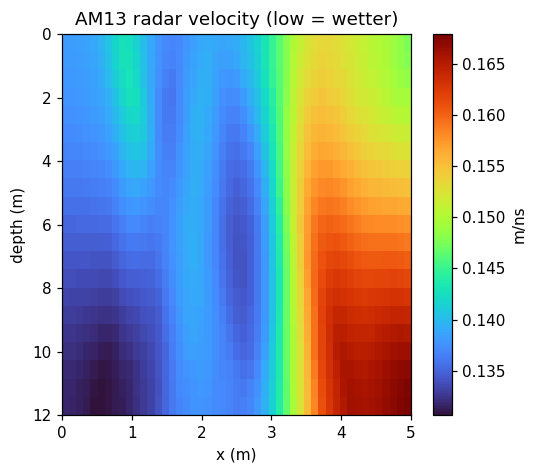

In [3]:
s_hat = invert(tt, beta=5.0); v = (1.0/s_hat).reshape(shape)
misfit = np.sqrt(np.mean(((G @ s_hat - tt)/std)**2))
eps = (0.2998/v)**2                                    # relative permittivity from velocity
theta = -5.3e-2 + 2.92e-2*eps - 5.5e-4*eps**2 + 4.3e-6*eps**3   # Topp (1980) volumetric water content
print('velocity %.3f-%.3f m/ns (median %.3f); data misfit %.2f sigma (fits to the noise)'
      % (np.percentile(v,5), np.percentile(v,95), np.median(v), misfit))
print('implied water content theta: %.0f-%.0f %% (Topp)' % (100*np.percentile(theta,5), 100*np.percentile(theta,95)))
gv.tomogram(v.T, (gx, gz), title='AM13 radar velocity (low = wetter)', clabel='m/ns');

## 4. How much of that image is real? The checkerboard test

The honest question is not "what does the tomogram show" but "what could it show". Put a **known** chequerboard
of $\pm12\%$ slowness anomalies into the *same* forward operator, add the real noise, invert with the *same*
regularization, and compare recovered to truth. Two things jump out and they are the whole point: the recovered
amplitude is only a **fraction** of the input (smearing), and the recovery is strongly **anisotropic** —
vertical layering is recovered far better than horizontal structure, because the sub-horizontal rays integrate
*across* the panel and cannot localize an anomaly along their own length.

checkerboard: recovered amplitude is 18% of the true anomaly (median, where rays reach)
directional resolution: vertical (layering) 33%  vs  horizontal 18%  of true amplitude


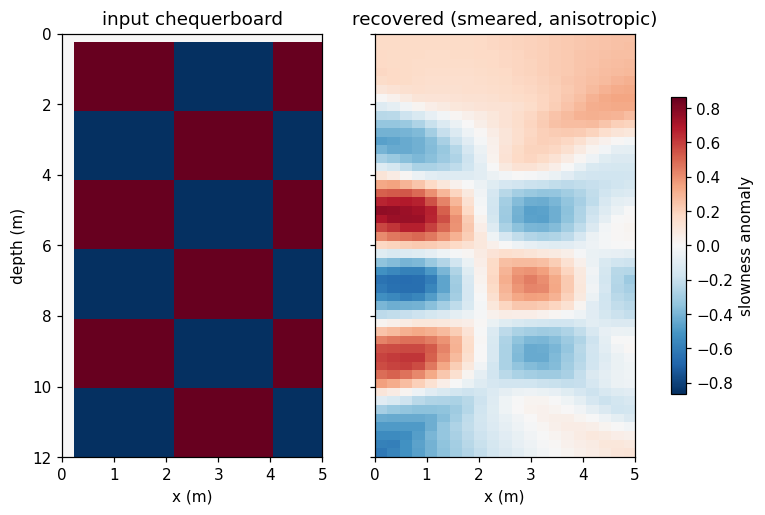

In [4]:
xx, zz = np.meshgrid(np.arange(nx), np.arange(nz), indexing='ij'); s0 = np.median(s_hat)
def recover(true_model):                               # forward the known model, add real noise, re-invert
    t = G @ true_model.ravel() + np.random.RandomState(0).randn(len(tt))*std
    return invert(t, beta=5.0).reshape(shape)
cb = s0*(1 + 0.12*np.sign(np.sin(np.pi*xx/8)*np.sin(np.pi*zz/8)))
cb_rec = recover(cb)
ratio = (cb_rec - s0)/(cb - s0); ratio[coverage < 3] = np.nan
print('checkerboard: recovered amplitude is %.0f%% of the true anomaly (median, where rays reach)' % (100*np.nanmedian(ratio)))
# directional stripes: along-borehole (vertical, z) vs across (horizontal, x)
def stripe_recovery(axis):
    m = s0*(1 + 0.12*np.sign(np.sin(np.pi*(zz if axis=='z' else xx)/6)))
    a = (recover(m) - s0)/(m - s0); a[coverage < 3] = np.nan; return 100*np.nanmedian(a)
print('directional resolution: vertical (layering) %.0f%%  vs  horizontal %.0f%%  of true amplitude'
      % (stripe_recovery('z'), stripe_recovery('x')))
fig, ax = plt.subplots(1, 2, figsize=(8.4, 5), sharey=True)
for a, (M, t) in zip(ax, [(cb, 'input chequerboard'), (cb_rec, 'recovered (smeared, anisotropic)')]):
    im = a.imshow(((M.reshape(shape)-s0)).T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='RdBu_r', aspect='auto', vmin=-0.12*s0, vmax=0.12*s0)
    a.set(title=t, xlabel='x (m)'); ax[0].set_ylabel('depth (m)')
fig.colorbar(im, ax=ax, shrink=0.7, label='slowness anomaly'); plt.show()

## 5. The point-spread: how a single anomaly smears

The sharpest statement of resolution is the **point-spread function**: invert the response of a *single* anomalous
cell and watch where its mass lands. A perfectly resolved survey would return the spike intact; here it spreads
into a horizontal streak — the inversion cannot tell a compact body from a horizontal smear of the same
traveltime effect. Any small horizontal feature you read off the tomogram is, to first order, this streak.

point-spread full-width at half-max:  horizontal 2.5 m  vs  vertical 0.8 m  (horizontal smear >> vertical)


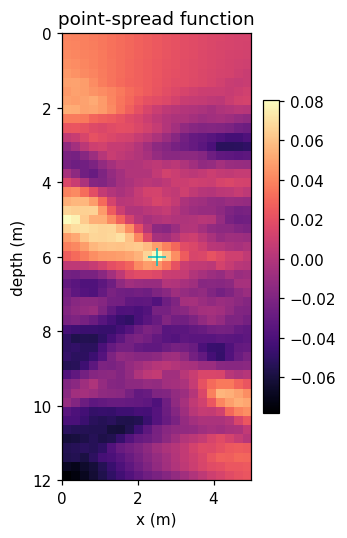

In [5]:
spike = np.full(shape, s0); spike[nx//2, nz//2] = s0*1.30          # one cell, +30% slow
psf = (recover(spike) - s0)
fwhm_x = np.sum(psf[:, nz//2] > 0.5*psf.max())*dx; fwhm_z = np.sum(psf[nx//2, :] > 0.5*psf.max())*dx
print('point-spread full-width at half-max:  horizontal %.1f m  vs  vertical %.1f m  (horizontal smear >> vertical)'
      % (fwhm_x, fwhm_z))
fig, a = plt.subplots(figsize=(3.2, 5))
im = a.imshow(psf.T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='magma', aspect='auto')
a.plot(gx[nx//2], gz[nz//2], 'c+', ms=12); a.set(title='point-spread function', xlabel='x (m)', ylabel='depth (m)')
fig.colorbar(im, ax=a, shrink=0.7); plt.tight_layout(); plt.show()

## 6. The regularizer is a choice, not a measurement

Because the data leave a null space, *something* must fill it — and that something is the smoothness prior,
tuned by $\beta$. Sweeping $\beta$ traces the **trade-off (L-) curve** between data misfit and model roughness:
too small and the tomogram chases noise into spurious structure; too large and it smears real contrasts away.
The point for interpretation is blunt — **the texture of the image is partly the analyst's prior**, so a feature
that survives only at one $\beta$ is not a robust target.

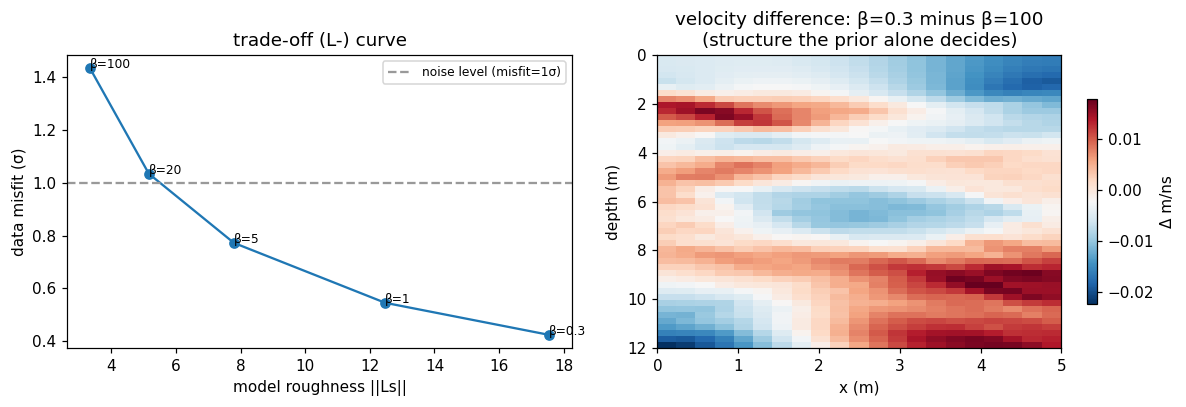

In [6]:
betas = [0.3, 1, 5, 20, 100]; misfits, roughs = [], []
for b in betas:
    sb = invert(tt, b); misfits.append(np.sqrt(np.mean(((G@sb-tt)/std)**2))); roughs.append(np.linalg.norm(L@sb))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(roughs, misfits, 'o-');
for b,r,m in zip(betas,roughs,misfits): ax[0].annotate(f'β={b}', (r,m), fontsize=8)
ax[0].axhline(1, ls='--', color='0.6', label='noise level (misfit=1σ)')
ax[0].set(xlabel='model roughness ||Ls||', ylabel='data misfit (σ)', title='trade-off (L-) curve'); ax[0].legend(fontsize=8)
im = ax[1].imshow((1/invert(tt,0.3)).reshape(shape).T - (1/invert(tt,100)).reshape(shape).T,
                  extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='RdBu_r', aspect='auto')
ax[1].set(title='velocity difference: β=0.3 minus β=100\n(structure the prior alone decides)', xlabel='x (m)', ylabel='depth (m)')
fig.colorbar(im, ax=ax[1], shrink=0.7, label='Δ m/ns'); plt.tight_layout(); plt.show()

## 7. The decision

Stated as a hydrogeologist should, separating the resolved from the assumed:

- **What the data resolve.** A coherent, sub-horizontal **low-velocity (wetter) interval** — vertical layering
  is the best-resolved structure here (checkerboard recovery several-fold better vertically than horizontally),
  so the *depth* and *vertical extent* of the wet zone are trustworthy, and the Topp conversion gives a
  defensible water-content range across it.
- **What the data do not resolve.** Absolute anomaly *amplitude* (recovered at only a fraction of truth — the
  Topp water contents are biased toward the panel mean), fine *horizontal* structure (the point-spread is a
  horizontal streak), and the **corners**, where no ray reaches and the image is pure prior.
- **What the prior decides.** The smoothness of the picture moves with $\beta$; features that appear only at low
  damping are not robust. A target worth acting on must survive the L-curve and sit where rays actually cross.
- **The honest deliverable.** Not a crisp water-content map, but a *resolution-qualified* one: the well-resolved
  vertical water-content profile with its smearing and coverage stated, and a clear flag on the parts of the
  panel that are interpolation. That is what keeps a remediation or aquifer decision from chasing an artifact.

This is the imaging counterpart of the course's recurring lesson: the picture is only as good as its
resolution, and quantifying the resolution *is* the result.

### Limitations
Straight rays approximate the physics; strong velocity contrasts bend rays (and create shadow zones), for which
an **eikonal / bent-ray** forward (`mixle_pde.eikonal_traveltime`) and iteration are needed — it sharpens
the tomogram but does not remove the null space. First-arrival tomography sees only the *fastest* path, blind to
low-velocity inclusions a wave goes around; full-waveform inversion uses the rest of the trace. Topp's equation
is lithology-dependent (CRIM or a site calibration is better), and the 2-D panel assumes the structure is
invariant out of plane.

### References
Maurer & Musil / the AM13 crosshole dataset (as distributed with pyGIMLi); Topp, Davis & Annan (1980), *Water
Resour. Res.* 16 (permittivity–water content); Menke, *Geophysical Data Analysis: Discrete Inverse Theory* (the
model-resolution matrix); Day-Lewis et al. (2005), *J. Geophys. Res.* (resolution-dependent petrophysics in GPR
tomography); Williamson & Worthington (1993) (resolution limits of crosshole tomography).

### Exercises
1. **Bent rays.** Swap `straight_ray_operator` for an eikonal forward (`mixle_pde.eikonal_traveltime`) and
   iterate; how much does the checkerboard recovery improve, and does the anisotropy persist?
2. **The resolution matrix.** Form $R=(G^\top W G+\beta L^\top L)^{-1}G^\top W G$ explicitly for a coarse grid
   and read each cell's resolution kernel — the formal version of §4–§5.
3. **Survey design.** Add a surface-to-borehole fan of rays and show which part of the null space it fills (tie
   to value-of-information: which new rays most reduce the unresolved volume?).
4. **Petrophysics uncertainty.** Propagate a $\pm$ on Topp's coefficients *and* the resolution bias into the
   water-content estimate — the honest error bar on the number a decision uses.